In [3]:
# Exploratory Data Analysis (EDA):
# 1.	Load the Titanic dataset using Python's pandas library.
# 2.	Check for missing values.
# 3.	Explore data distributions using histograms and box plots.
# 4.	Visualize relationships between features and survival using scatter plots and bar plots.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
#load the data
data = pd.read_csv('diabetes.csv')

In [3]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [6]:
data.shape

(768, 9)

In [7]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

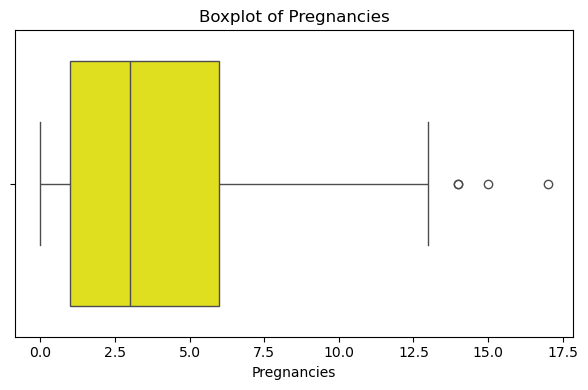

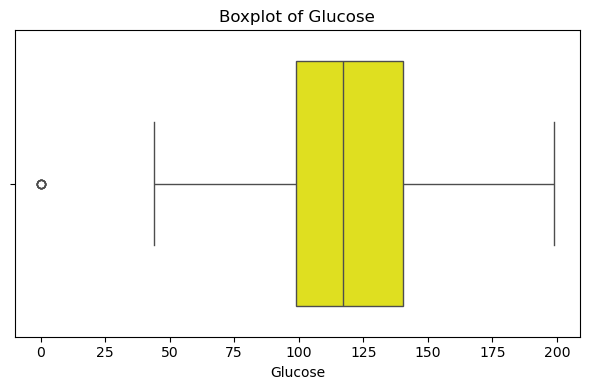

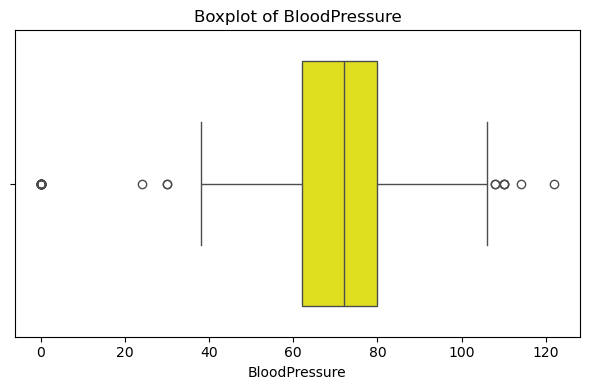

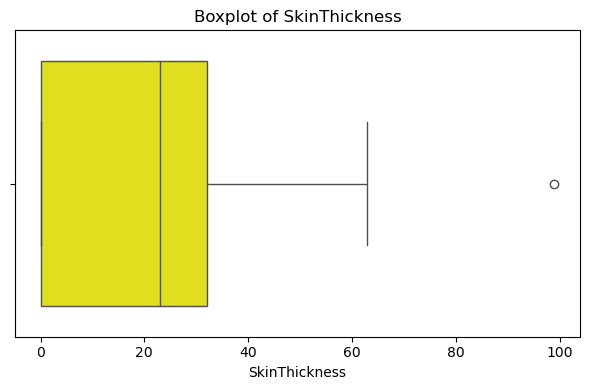

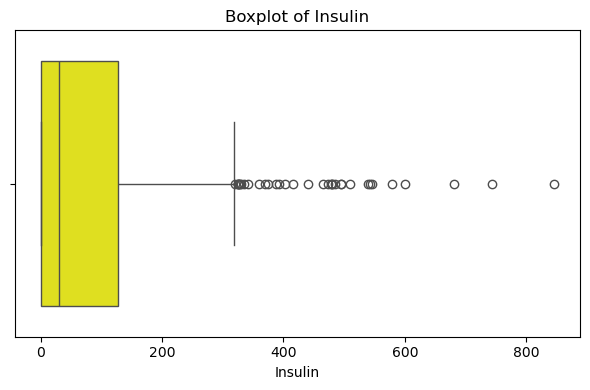

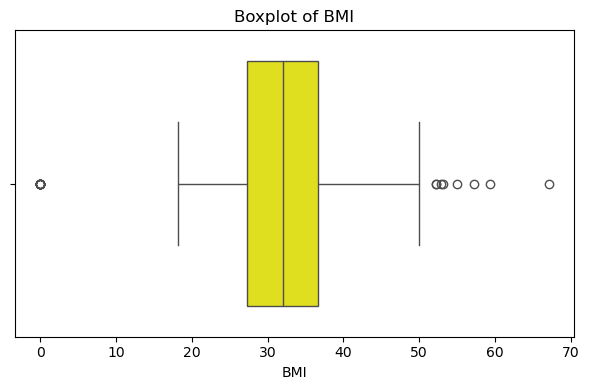

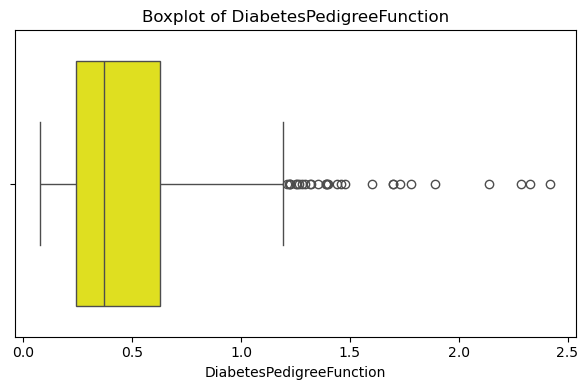

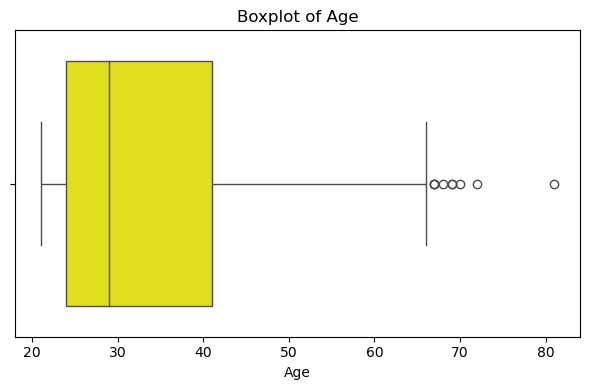

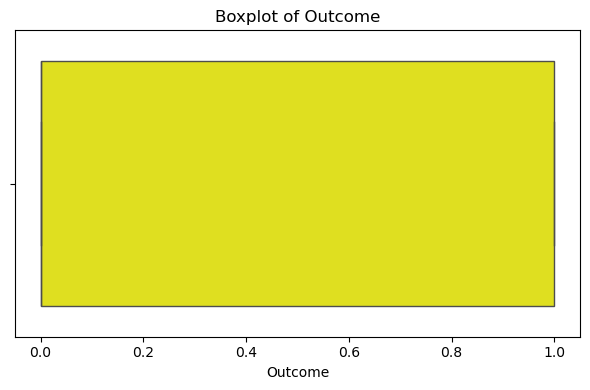

In [9]:
#box plot
for col in data:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[col], color = 'Yellow')
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [10]:
def outlier_capping(data,column):
    Q1= data[column].quantile(0.25)
    Q3= data[column].quantile(0.75)
    IQR =Q3-Q1
    Lower_Extreme= Q1-1.5*IQR
    Upper_Extreme= Q3+1.5*IQR
    data[column]= data[column].apply(lambda x: Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in data.select_dtypes(['int','float']).columns:
    outlier_capping(data,col)

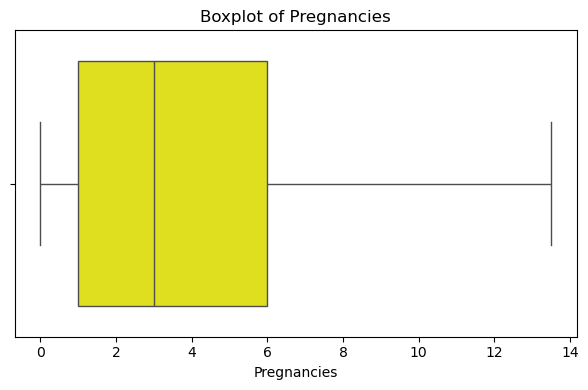

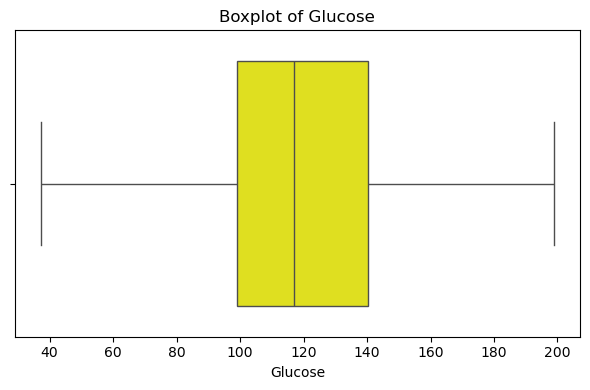

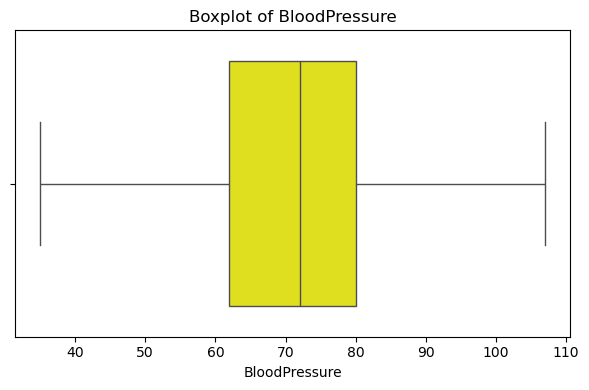

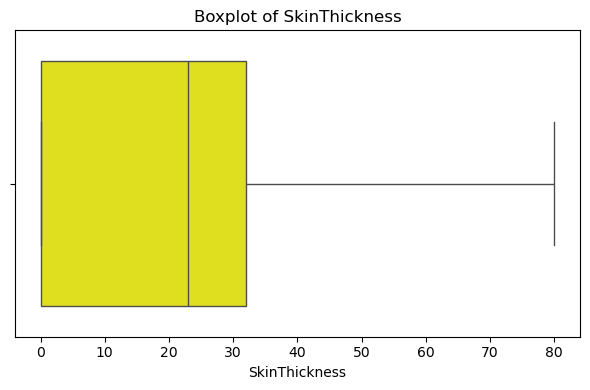

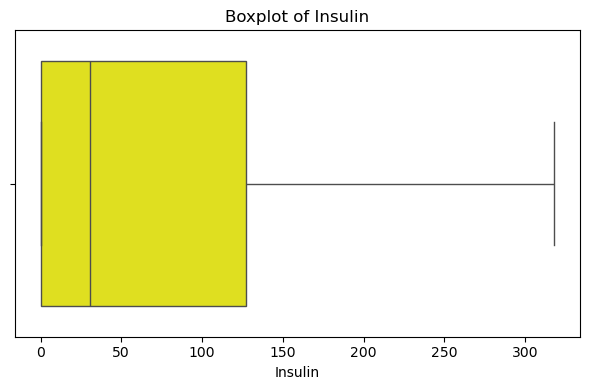

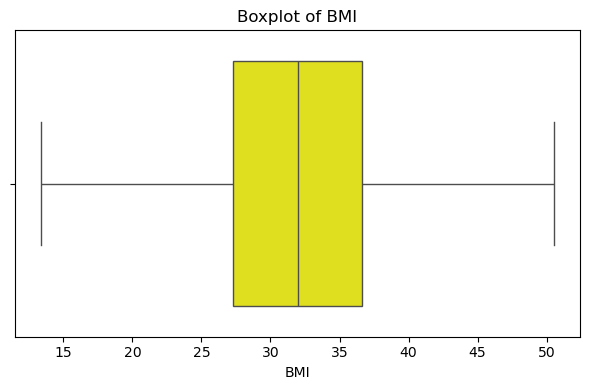

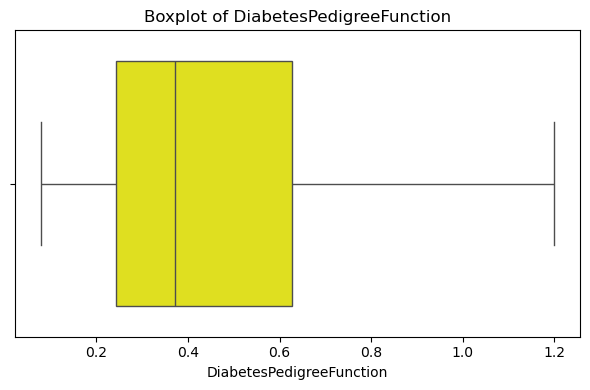

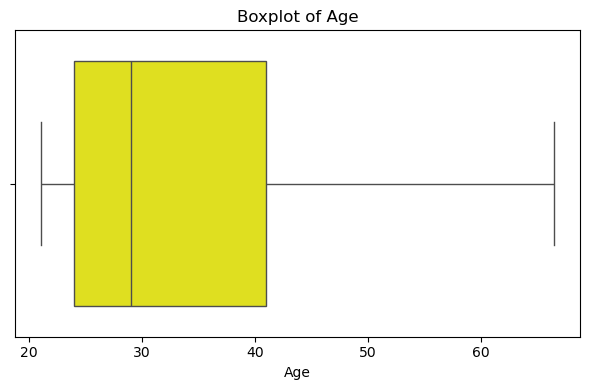

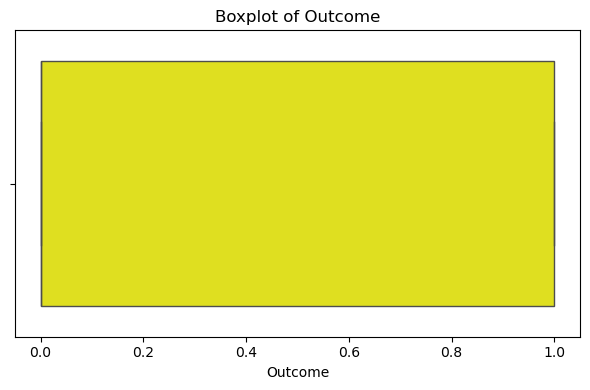

In [11]:
for col in data:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[col], color = 'Yellow')
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

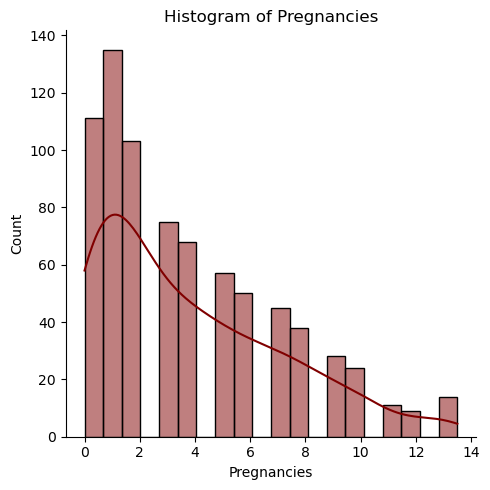

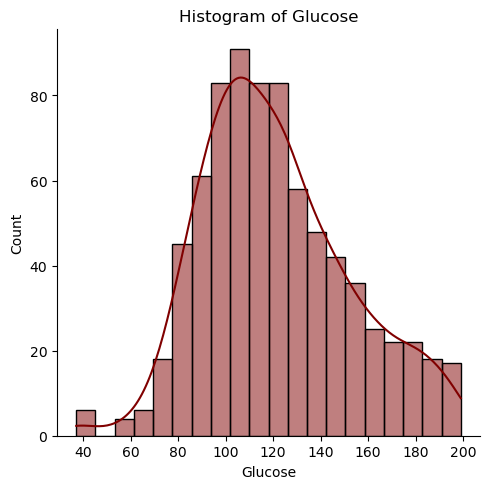

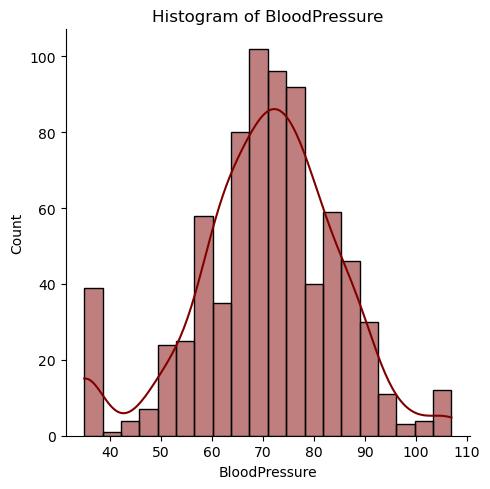

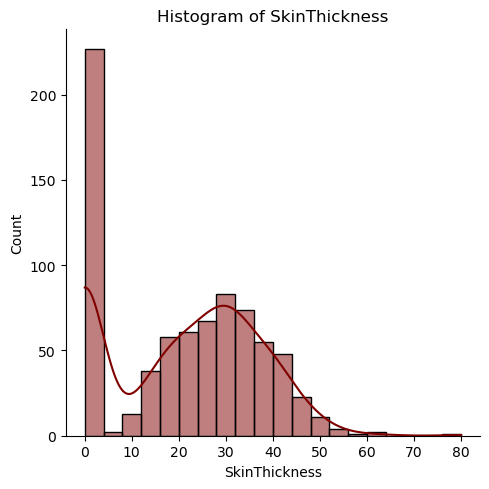

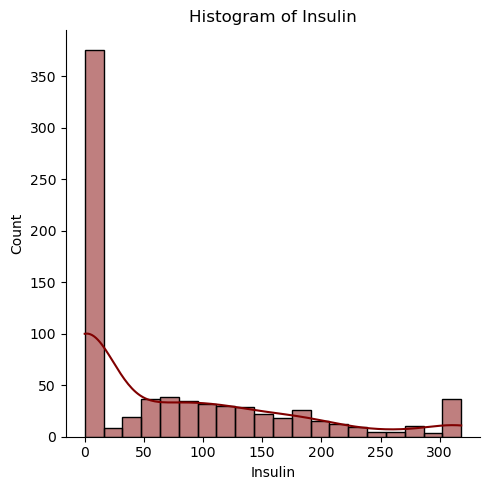

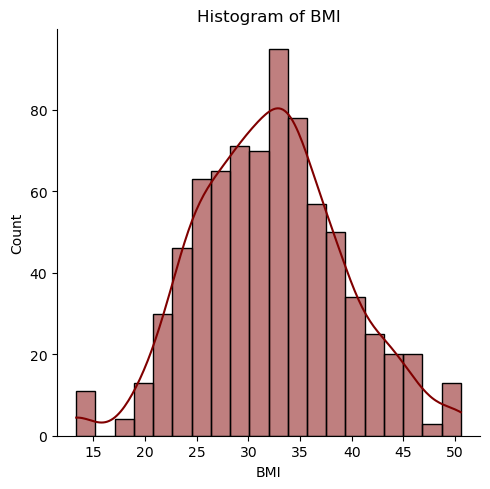

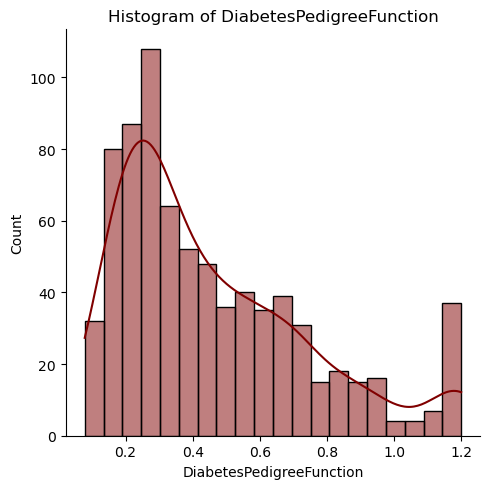

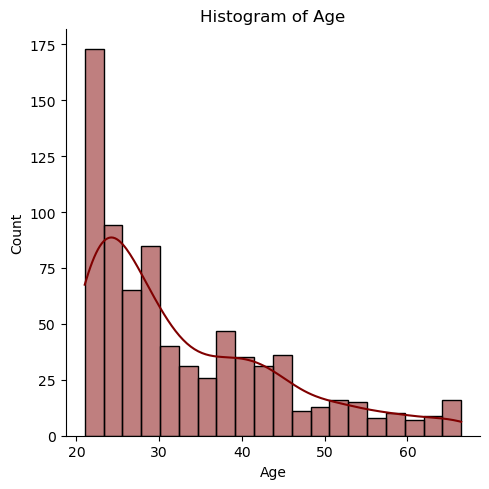

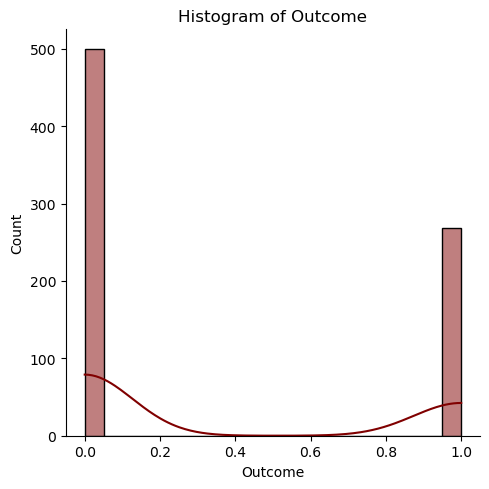

In [12]:
#hist plot 
for col in data:
    sns.displot(data=data, x=col, bins=20, kde=True,color='Maroon')
    plt.title(f"Histogram of {col}")
    plt.tight_layout()
    plt.show()

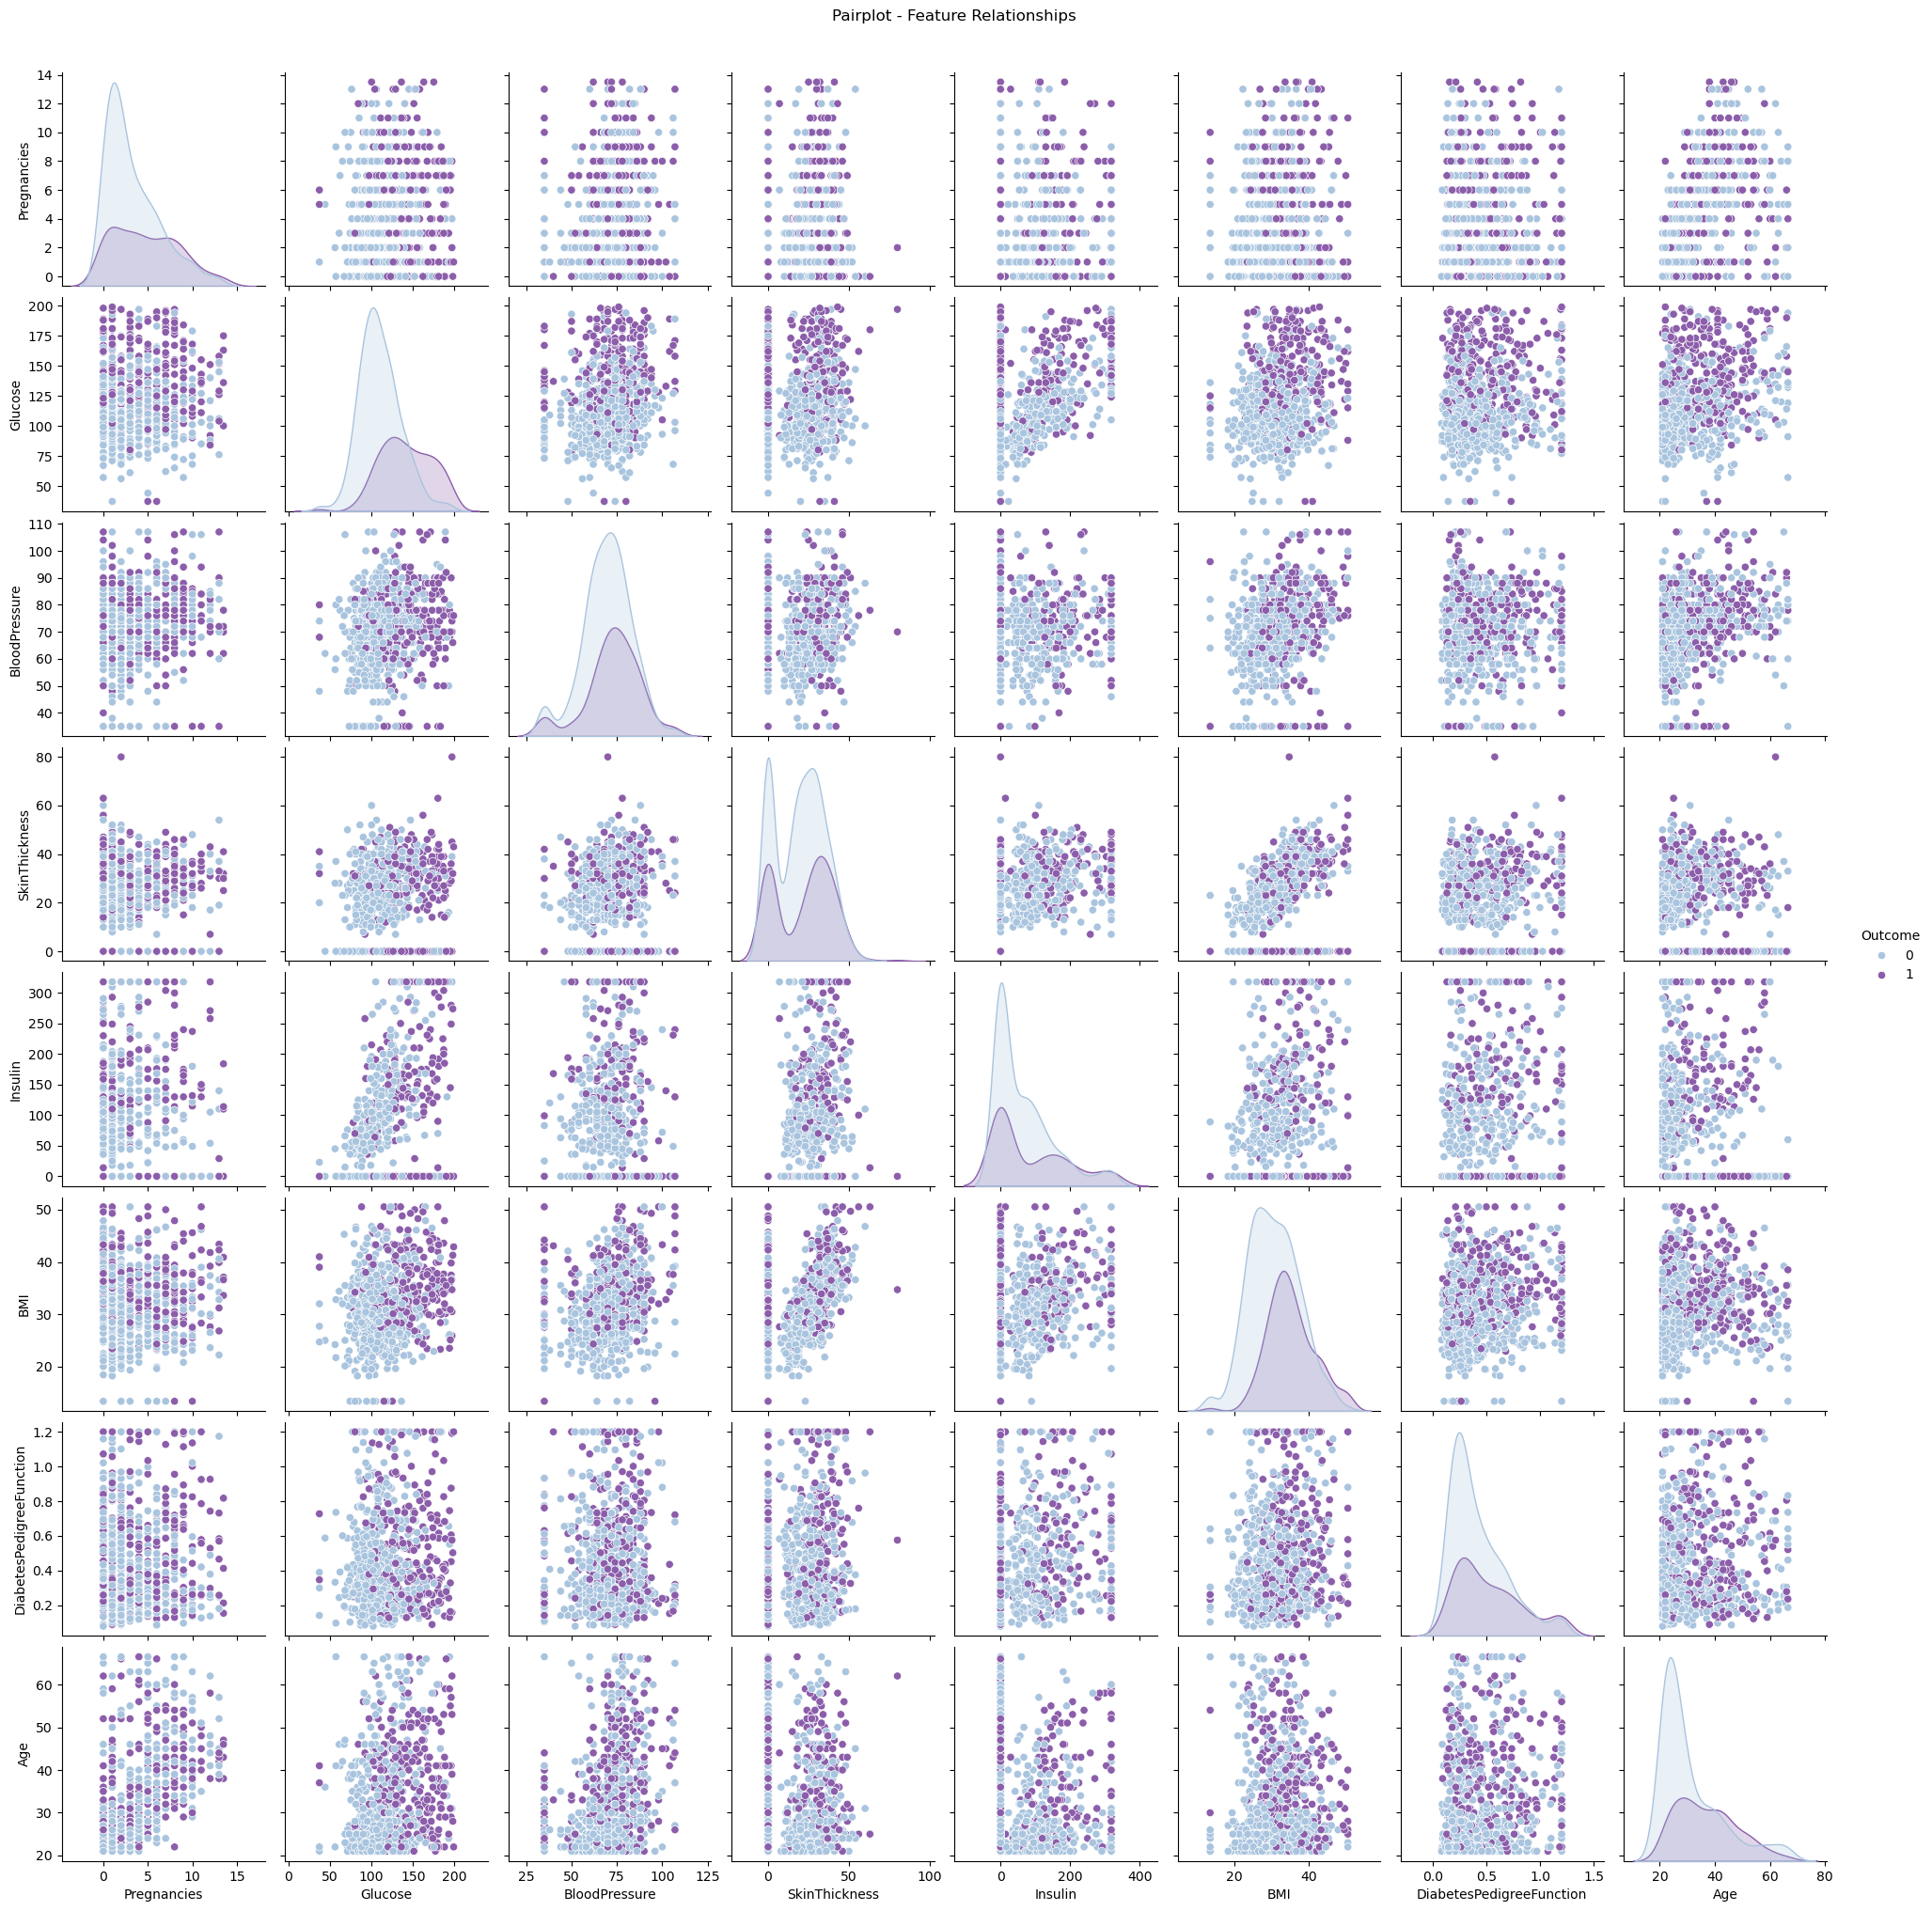

In [13]:
sns.pairplot(data, hue="Outcome", palette="BuPu")
plt.suptitle("Pairplot - Feature Relationships", y=1.02)
plt.show()

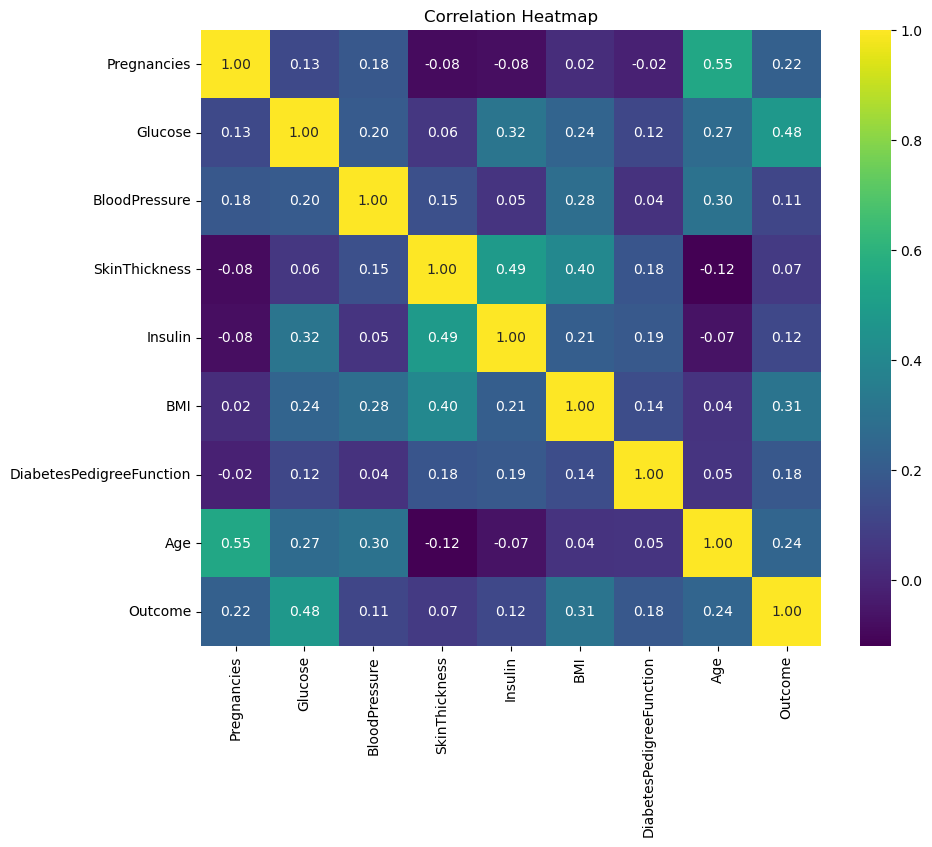

In [14]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# Data Preprocessing:
# 1.	Impute missing values.
# 2.	Encode categorical variables using one-hot encoding or label encoding.
# 3.	If needed you can apply more preprocessing methods on the given dataset.


In [16]:
#check for null values
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [17]:
# Separate Features & Target
features = data.drop("Outcome", axis=1)
target = data["Outcome"]

In [20]:
# Identify Numeric and Categorical Features
numeric_features = features.select_dtypes(include=['int64', 'float64']).columns
categorical_features = features.select_dtypes(include=['object']).columns

print("Numeric Features:", list(numeric_features))
print("Categorical Features:", list(categorical_features))

Numeric Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Categorical Features: []


In [21]:
#pip install xgboost

In [ ]:
pip install lightgbm


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Build Preprocessing Pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [ ]:
# Building Predictive Models:
# 1.	Split the preprocessed dataset into training and testing sets.
# 2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.
# 3.	Build predictive models using LightGBM and XGBoost algorithms.
# 4.	Train the models on the training set and evaluate their performance on the testing set.


In [ ]:
#split the data
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, stratify=target, random_state=42)
print(X_train.shape, X_test.shape)

In [ ]:
#build the pipeline
lgbm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(random_state=42))
])


In [ ]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(eval_metric='logloss', random_state=42))
])

In [ ]:
lgbm_params = {
    'model__n_estimators': [50, 100],
    'model__learning_rate': [0.1, 0.01],
    'model__num_leaves': [31, 63]
}

In [ ]:
grid_lgbm = GridSearchCV(lgbm_model, lgbm_params, cv=5, scoring='accuracy')
grid_lgbm.fit(X_train, y_train)

In [ ]:
print("Best LGBM Parameters:", grid_lgbm.best_params_)

In [ ]:
xgb_params = {
    'model__n_estimators': [50, 100],
    'model__learning_rate': [0.1, 0.01],
    'model__max_depth': [3, 5]
}

In [ ]:
grid_xgb = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='accuracy')
grid_xgb.fit(X_train, y_train)

In [ ]:
print("Best XGB Parameters:", grid_xgb.best_params_)

In [ ]:
models = {
    "LightGBM": grid_lgbm.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))

In [ ]:
# Comparative Analysis:
# 1.	Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.
# 2.	Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.


In [ ]:
## Compare Metrics
results_df = pd.DataFrame(results).T
results_df

In [ ]:
# Plot Metric Comparison
results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.show()

In [ ]:
#Comparitive summary
print("\nXGBoost vs LightGBM:")
print(results_df)

#### LightGBM performs better on large datasets and is faster.
#### XGBoost is more robust and stable, especially on smaller datasets.

### Strengths & Weaknesses Summary	
#### LightGBM - Strengths :	Very fast, handles big data well	
#### Weaknesses:  Can overfit
#### XGBoost -	Strengths : Stable, accurate, less overfitting	Slowe
#### Weaknesses: more memory